In [1]:
import pandas as pd
import numpy as np

# 데이터 불러오기
customers = pd.read_csv("data/customer_hm.csv")
transactions = pd.read_csv("data/transactions_hm.csv")
articles = pd.read_csv("data/articles_hm.csv")

In [3]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column                  Non-Null Count    Dtype
---  ------                  --------------    -----
 0   customer_id             1048575 non-null  str  
 1   FN                      1048575 non-null  int64
 2   Active                  1048575 non-null  int64
 3   club_member_status      1048575 non-null  str  
 4   fashion_news_frequency  1048574 non-null  str  
 5   age                     1048575 non-null  int64
dtypes: int64(3), str(3)
memory usage: 48.0 MB


In [4]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   t_dat             1048575 non-null  str    
 1   customer_id       1048575 non-null  str    
 2   article_id        1048575 non-null  int64  
 3   price             1048575 non-null  float64
 4   sales_channel_id  1048575 non-null  int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 40.0 MB


In [5]:
articles.info()

<class 'pandas.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   article_id                    105542 non-null  int64
 1   product_code                  105542 non-null  int64
 2   prod_name                     105542 non-null  str  
 3   product_type_no               105542 non-null  int64
 4   product_type_name             105542 non-null  str  
 5   product_group_name            105542 non-null  str  
 6   graphical_appearance_no       105542 non-null  int64
 7   graphical_appearance_name     105542 non-null  str  
 8   colour_group_code             105542 non-null  int64
 9   colour_group_name             105542 non-null  str  
 10  perceived_colour_value_id     105542 non-null  int64
 11  perceived_colour_value_name   105542 non-null  str  
 12  perceived_colour_master_id    105542 non-null  int64
 13  perceived_colour_master_n

In [2]:
# customers 카피본 생성 -> fashion news frequency 버림
customers_copy1 = customers.drop(columns = ["fashion_news_frequency"])
customers_copy1

,customer_id,FN,Active,club_member_status,age
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0,0,ACTIVE,49
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0,0,ACTIVE,25
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,0,0,ACTIVE,24
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,0,0,ACTIVE,54
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1,1,ACTIVE,52
...,...,...,...,...,...
1048570,c88f5971612e659a4e90d6f08d9c29bdf1e4268fcf52d5...,1,1,ACTIVE,22
1048571,c88f5d0deba322a686e7928da6a7f3d2318e102d1c2cdb...,1,1,ACTIVE,41
1048572,c88f99a55b10f6dd50dd87c3ca05af4a8a6c98f3e6fbc5...,0,0,ACTIVE,38
1048573,c88fa15c06519c4bdcab386fea313b226113584b729874...,1,1,ACTIVE,54


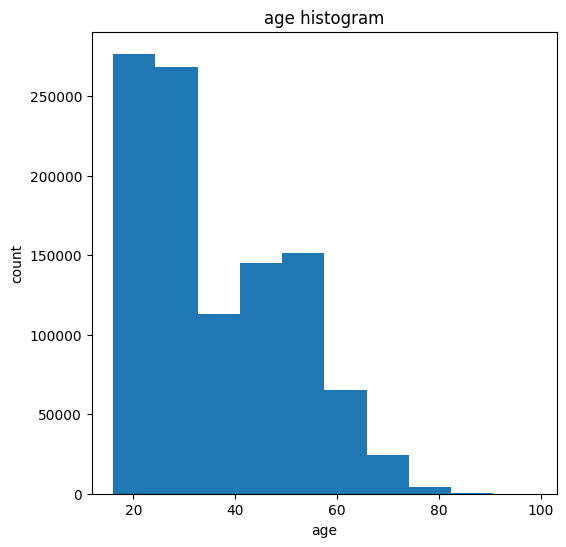

In [9]:
# age의 나이대 파생컬럼을 만들기 전 이상치 확인용 히스토그램
import matplotlib.pyplot as plt
customers_copy2 = customers_copy1.copy()

plt.figure(figsize = (6, 6))
plt.hist(customers_copy2["age"], bins = 10)
plt.xlabel("age")
plt.ylabel("count")
plt.title("age histogram")
plt.show()

In [10]:
# age의 나이대 파생컬럼 "age_group" 생성
customers_copy2["age_group"] = "10대"
customers_copy2.loc[customers_copy2["age"] < 100, "age_group"] = "70대+"
customers_copy2.loc[customers_copy2["age"] <= 69, "age_group"] = "60대"
customers_copy2.loc[customers_copy2["age"] <= 59, "age_group"] = "50대"
customers_copy2.loc[customers_copy2["age"] <= 49, "age_group"] = "40대"
customers_copy2.loc[customers_copy2["age"] <= 39, "age_group"] = "30대"
customers_copy2.loc[customers_copy2["age"] <= 29, "age_group"] = "20대"

customers_copy2["age_group"].value_counts()

age_group
20대     464452
30대     181112
50대     174715
40대     157445
60대      56124
70대+     14727
Name: count, dtype: int64

In [12]:
# transactions 전처리를 위한 카피본 생성
transactions_copy1 = transactions.copy()

In [13]:
# t_dat 컬럼 전처리 전 형식 일치 확인
transactions_copy1[transactions_copy1["t_dat"].str.contains("-") == False]

,t_dat,customer_id,article_id,price,sales_channel_id


In [14]:
# t_dat의 데이터형 문자열 -> 날짜데이터 변환
transactions_copy1["t_dat"] = pd.to_datetime(transactions_copy1["t_dat"])
transactions_copy1["t_dat"]

0         2019-11-05
1         2019-05-22
2         2019-05-10
3         2019-08-26
4         2019-08-10
             ...    
1048570   2019-03-25
1048571   2019-10-18
1048572   2019-04-06
1048573   2019-03-20
1048574   2019-01-13
Name: t_dat, Length: 1048575, dtype: datetime64[us]

In [15]:
# t_dat의 데이터 '연-월' 형식 변환
transactions_copy1["t_dat"] = transactions_copy1["t_dat"].dt.to_period("M")

In [16]:
# 전처리 결과 확인
transactions_copy1["t_dat"].value_counts()

t_dat
2019-06    122043
2019-07    115505
2019-05     99728
2019-04     94073
2019-03     81858
2019-01     81248
2019-08     80219
2019-09     78545
2019-11     76358
2019-10     73820
2019-02     73730
2019-12     71448
Freq: M, Name: count, dtype: int64

In [17]:
articles_copy = articles.copy()

In [18]:
selected_cols = ['article_id', 'product_group_name', 'perceived_colour_master_name', 'index_name', 'garment_group_name']
articles_test = pd.read_csv('data/articles_hm.csv', usecols=selected_cols)

garment_mode = articles_test[articles_test['garment_group_name'] != 'Unknown']['garment_group_name'].mode()[0]
articles_test['garment_group_name'] = articles_test['garment_group_name'].replace('Unknown', garment_mode)

In [19]:
trans_cus = pd.merge(transactions_copy1, customers_copy2, on = "customer_id", how = "left")
trans_cus.isna().sum()

t_dat                      0
customer_id                0
article_id                 0
price                      0
sales_channel_id           0
FN                    235644
Active                235644
club_member_status    235644
age                   235644
age_group             235644
dtype: int64

In [ ]:
trans_cus_arc = pd.merge(trans_cus, articles_test, on = "article_id", how = "left")
trans_cus_arc['product_group_name'].value_counts()

product_group_name
Garment Upper body       415881
Garment Lower body       232472
Garment Full body        117701
Swimwear                  89657
Underwear                 80652
Accessories               52220
Shoes                     25554
Socks & Tights            21267
Nightwear                 11283
Unknown                    1475
Bags                        221
Items                       111
Cosmetic                     29
Furniture                    29
Underwear/nightwear          17
Garment and Shoe care         5
Interior textile              1
Name: count, dtype: int64